# Scientific Paper Title Generation

Fine-tune a pre-trained encoder-decoder language model (T5-small) to generate a compelling title for a scientific paper given its abstract. This is an abstractive text summarization task using the [arXiv Dataset](https://drive.google.com/drive/folders/1b8JznRVbkYom1iIZFoBErdfksYsPk6kw) containing metadata for scientific papers.

# 1. Environment Setup & Library Installation
In this initial step, we configure the execution environment:

Library Installation: Installing transformers, datasets, and evaluation metrics (rouge_score, sacrebleu).

Imports: Importing necessary modules for PyTorch, Pandas, and visualization.

Reproducibility: Setting a fixed random_seed to ensure consistent results across runs.

Hardware Check: Verifying GPU availability (CUDA) to accelerate the fine-tuning process


In [ ]:
# ============================================================
# PART 1: SETUP & INSTALLATION
# ============================================================

# Install required libraries
!pip install -q transformers datasets evaluate rouge-score bert-score sacrebleu sentencepiece accelerate -U

# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# Transformers & PyTorch
import torch
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    Seq2SeqTrainingArguments,
    Seq2SeqTrainer,
    DataCollatorForSeq2Seq
)
from datasets import Dataset, DatasetDict
import evaluate

# Set random seeds for reproducibility
import random
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory Available: {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")

print("\n Setup completed successfully!")

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.6/511.6 kB 24.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.7/47.7 MB 13.7 MB/s eta 0:00:00
Using device: cuda
GPU: Tesla T4
Memory Available: 15.83 GB

 Setup completed successfully!


#2.DATA LOADING
Here, we load and inspect the dataset to understand its structure:

Data Loading: Mounting Google Drive and reading the arXiv_scientific_dataset.csv.

Data Cleaning: Checking for and removing null values to ensure data integrity.

Visualization: Plotting the distribution of word counts for both Abstracts (inputs) and Titles (targets) to determine optimal sequence lengths for the model.

Mounted at /content/drive
Loading dataset...
 Dataset loaded: 136238 samples

 Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 136238 entries, 0 to 136237
Data columns (total 10 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   id                  136238 non-null  object
 1   title               136238 non-null  object
 2   category            136238 non-null  object
 3   category_code       136238 non-null  object
 4   published_date      136238 non-null  object
 5   updated_date        136238 non-null  object
 6   authors             136238 non-null  object
 7   first_author        136238 non-null  object
 8   summary             136238 non-null  object
 9   summary_word_count  136238 non-null  int64 
dtypes: int64(1), object(9)
memory usage: 10.4+ MB
None

 First few rows:
             id                                              title  \
0  cs-9308101v1                               Dynamic Backtracki

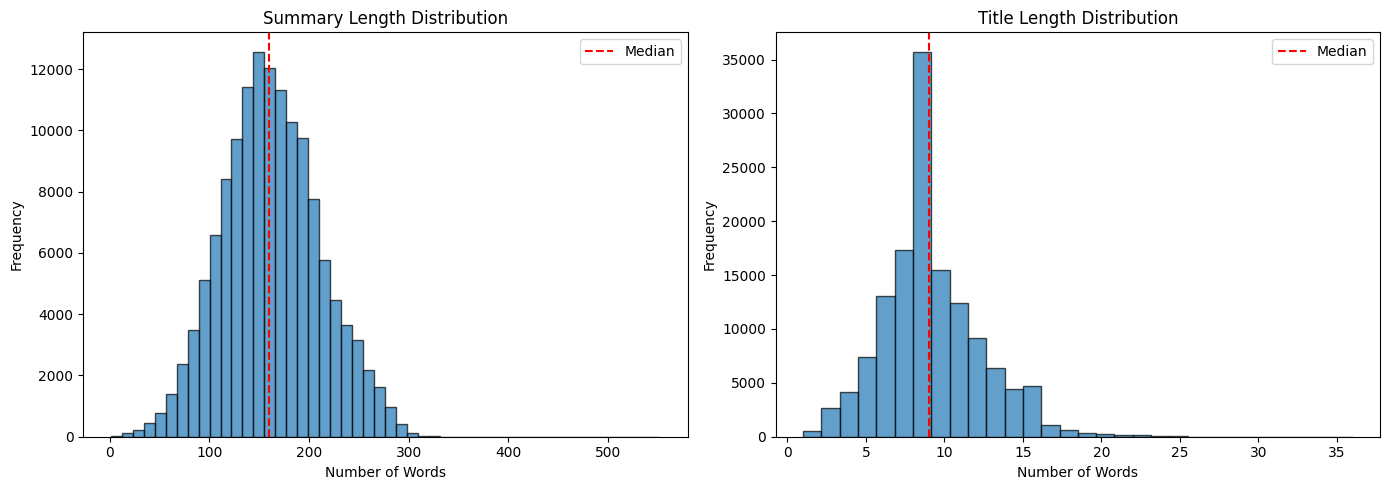


 Sample Papers:

--- Example 1 ---
Title: Dynamic Backtracking
Summary (first 200 chars): Because of their occasional need to return to shallow points in a search
tree, existing backtracking methods can sometimes erase meaningful progress
toward solving a search problem. In this paper, we ...
Summary length: 79 words
Title length: 2 words

--- Example 2 ---
Title: A Market-Oriented Programming Environment and its Application to
  Distributed Multicommodity Flow Problems
Summary (first 200 chars): Market price systems constitute a well-understood class of mechanisms that
under certain conditions provide effective decentralization of decision making
with minimal communication overhead. In a mark...
Summary length: 119 words
Title length: 12 words

--- Example 3 ---
Title: An Empirical Analysis of Search in GSAT
Summary (first 200 chars): We describe an extensive study of search in GSAT, an approximation procedure
for propositional satisfiability. GSAT performs greedy hill-climbing on th

In [ ]:
# ============================================================
# PART 2: LOAD & EXPLORE DATA
# ============================================================

# Mount Google Drive (if data is stored there)
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
data_path = '/content/drive/MyDrive/arXiv_scientific dataset.csv'  # Update your path

# Load CSV
print("Loading dataset...")
df = pd.read_csv(data_path)
print(f" Dataset loaded: {len(df)} samples")

# Display basic information
print("\n Dataset Info:")
print(df.info())

print("\n First few rows:")
print(df.head())

# Check columns
print("\n Columns:", df.columns.tolist())

# Identify the summary and title columns
# Based on the image, it seems 'summary' column is for abstract and 'title' column is for title
summary_col = 'summary'
title_col = 'title'

# Check for missing values
print("\n Missing values:")
print(df[[summary_col, title_col]].isnull().sum())

# Remove rows with missing values
df_clean = df[[summary_col, title_col]].dropna()
print(f"\n After removing missing values: {len(df_clean)} samples")

# Analyze text lengths
df_clean['summary_length'] = df_clean[summary_col].str.split().str.len()
df_clean['title_length'] = df_clean[title_col].str.split().str.len()

print("\n Text Length Statistics:")
print(df_clean[['summary_length', 'title_length']].describe())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_clean['summary_length'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_title('Summary Length Distribution')
axes[0].set_xlabel('Number of Words')
axes[0].set_ylabel('Frequency')
axes[0].axvline(df_clean['summary_length'].median(), color='red', linestyle='--', label='Median')
axes[0].legend()

axes[1].hist(df_clean['title_length'], bins=30, edgecolor='black', alpha=0.7)
axes[1].set_title('Title Length Distribution')
axes[1].set_xlabel('Number of Words')
axes[1].set_ylabel('Frequency')
axes[1].axvline(df_clean['title_length'].median(), color='red', linestyle='--', label='Median')
axes[1].legend()

plt.tight_layout()
plt.show()

# Sample examples
print("\n Sample Papers:")
for i in range(3):
    print(f"\n--- Example {i+1} ---")
    print(f"Title: {df_clean.iloc[i][title_col]}")
    print(f"Summary (first 200 chars): {df_clean.iloc[i][summary_col][:200]}...")
    print(f"Summary length: {df_clean.iloc[i]['summary_length']} words")
    print(f"Title length: {df_clean.iloc[i]['title_length']} words")

# 3.Data Sampling, Filtering & Splitting
To prepare the data for efficient training:

Sampling: We select a subset of the data (e.g., 30k samples) to balance training speed and performance.

Filtering: We remove outliers (texts that are too short or excessively long) to stabilize training.

Splitting: The dataset is divided into three sets:

Train (80%): For model learning.

Validation (10%): For hyperparameter tuning and monitoring.

Test (10%): For final, unbiased evaluation.


In [ ]:
# ============================================================
# PART 3: DATA SAMPLING & PREPROCESSING
# ============================================================

SAMPLE_SIZE = 30000

print(f" Using {SAMPLE_SIZE} samples for training")

# Sample data randomly
if len(df_clean) > SAMPLE_SIZE:
    df_sample = df_clean.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
else:
    df_sample = df_clean.reset_index(drop=True)

print(f" Sampled dataset: {len(df_sample)} samples")

# Filter out extremely long or short texts to improve training stability
MAX_SUMMARY_LENGTH = 512  # words
MIN_SUMMARY_LENGTH = 20
MAX_TITLE_LENGTH = 50
MIN_TITLE_LENGTH = 3

df_filtered = df_sample[
    (df_sample['summary_length'] >= MIN_SUMMARY_LENGTH) &
    (df_sample['summary_length'] <= MAX_SUMMARY_LENGTH) &
    (df_sample['title_length'] >= MIN_TITLE_LENGTH) &
    (df_sample['title_length'] <= MAX_TITLE_LENGTH)
].reset_index(drop=True)

print(f" After filtering: {len(df_filtered)} samples")

# Split data: 80% train, 10% validation, 10% test
train_size = int(0.8 * len(df_filtered))
val_size = int(0.1 * len(df_filtered))
test_size = len(df_filtered) - train_size - val_size

train_df = df_filtered[:train_size]
val_df = df_filtered[train_size:train_size+val_size]
test_df = df_filtered[train_size+val_size:]

print(f"\n Data Split:")
print(f"  Train: {len(train_df)} samples")
print(f"  Val:   {len(val_df)} samples")
print(f"  Test:  {len(test_df)} samples")

# Create datasets in Hugging Face format
def create_dataset(df):
    return Dataset.from_dict({
        'summary': df[summary_col].tolist(),
        'title': df[title_col].tolist()
    })

dataset_dict = DatasetDict({
    'train': create_dataset(train_df),
    'validation': create_dataset(val_df),
    'test': create_dataset(test_df)
})

print("\n Dataset created successfully!")
print(dataset_dict)

# Show sample
print("\n Sample from training set:")
sample = dataset_dict['train'][0]
print(f"Summary: {sample['summary'][:200]}...")
print(f"Title: {sample['title']}")

 Using 30000 samples for training
 Sampled dataset: 30000 samples
 After filtering: 29825 samples

 Data Split:
  Train: 23860 samples
  Val:   2982 samples
  Test:  2983 samples

 Dataset created successfully!
DatasetDict({
    train: Dataset({
        features: ['summary', 'title'],
        num_rows: 23860
    })
    validation: Dataset({
        features: ['summary', 'title'],
        num_rows: 2982
    })
    test: Dataset({
        features: ['summary', 'title'],
        num_rows: 2983
    })
})

 Sample from training set:
Summary: The preceding three decades have seen the emergence, rise, and proliferation
of machine learning (ML). From half-recognised beginnings in perceptrons,
neural nets, and decision trees, algorithms that ...
Title: Machine Learning and the Future of Realism


#4 . Model Initialization & Tokenization
We initialize the pre-trained model and prepare the text inputs:

Model Loading: Loading the t5-base (or t5-small) architecture from Hugging Face.

Tokenization: Converting raw text into input IDs using the specific T5 tokenizer.

Formatting: Prepending the required prefix "summarize: " to the input text, as T5 treats every NLP problem as a text-to-text task.

In [ ]:
# ============================================================
# PART 4: MODEL SETUP & TOKENIZATION
# ============================================================
MODEL_NAME = "t5-base"

print(f" Loading model: {MODEL_NAME}")

# Load tokenizer and model
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME)

print(f" Model loaded successfully!")
print(f"   Parameters: {model.num_parameters():,}")

# Set up tokenization parameters
MAX_INPUT_LENGTH = 512   # Maximum tokens for input (summary)
MAX_TARGET_LENGTH = 64   # Maximum tokens for output (title)

# Tokenization function
def preprocess_function(examples):
    # T5 requires a prefix for the task
    inputs = ["summarize: " + doc for doc in examples['summary']]
    model_inputs = tokenizer(
        inputs,
        max_length=MAX_INPUT_LENGTH,
        truncation=True,
        padding=False  # We'll pad dynamically during training
    )

    # Tokenize targets
    labels = tokenizer(
        examples['title'],
        max_length=MAX_TARGET_LENGTH,
        truncation=True,
        padding=False
    )

    model_inputs['labels'] = labels['input_ids']
    return model_inputs

# Apply tokenization to all splits
print("\n Tokenizing datasets...")
tokenized_datasets = dataset_dict.map(
    preprocess_function,
    batched=True,
    remove_columns=dataset_dict['train'].column_names,
    desc="Tokenizing"
)

print(" Tokenization completed!")
print(tokenized_datasets)

# Create data collator for dynamic padding
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding=True
)

# Show a tokenized example
print("\n Tokenized example:")
sample = tokenized_datasets['train'][0]
print(f"Input IDs shape: {len(sample['input_ids'])}")
print(f"Labels shape: {len(sample['labels'])}")
print(f"Decoded input: {tokenizer.decode(sample['input_ids'][:100])}...")
print(f"Decoded label: {tokenizer.decode(sample['labels'], skip_special_tokens=True)}")

🤖 Loading model: t5-base


config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/892M [00:00<?, ?B/s]

...

 Model loaded successfully!
   Parameters: 222,903,552

 Tokenizing datasets...


Tokenizing:   0%|          | 0/23860 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/2982 [00:00<?, ? examples/s]

Tokenizing:   0%|          | 0/2983 [00:00<?, ? examples/s]

 Tokenization completed!
DatasetDict({
    train: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 23860
    })
    validation: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2982
    })
    test: Dataset({
        features: ['input_ids', 'attention_mask', 'labels'],
        num_rows: 2983
    })
})

 Tokenized example:
Input IDs shape: 150
Labels shape: 9
Decoded input: summarize: The preceding three decades have seen the emergence, rise, and proliferation of machine learning (ML). From half-recognised beginnings in perceptrons, neural nets, and decision trees, algorithms that extract correlations (that is, patterns) from a set of data points have broken free from their origin in computational cognition to embrace all forms of problem solving, from voice recognition to medical diagnosis to automated scientific research and driverless cars, and it is now...
Decoded label: Machine Learning and the Future o

#5 . Training Configuration & Metrics Definition
Defining the hyperparameters and evaluation criteria:

Training Args: Setting the Learning Rate, Batch Size, Weight Decay, and Epochs. We enable fp16 (mixed precision) for faster GPU training.

Metrics: Implementing a compute_metrics function to calculate ROUGE (Recall-Oriented Understudy for Gisting Evaluation) and BLEU scores, which are standard metrics for summarization tasks.

In [ ]:
# ============================================================
# PART 5: TRAINING CONFIGURATION
# ============================================================

# Training hyperparameters
OUTPUT_DIR = "./results"

training_args = Seq2SeqTrainingArguments(
    output_dir=OUTPUT_DIR,

    # Training parameters
    num_train_epochs=3,
    per_device_train_batch_size=8,   # Batch size for training
    per_device_eval_batch_size=8,    # Batch size for evaluation
    gradient_accumulation_steps=4,   # Gain gradient to have larger batch size more effectively

    # Optimization
    learning_rate=5e-5,              # Learning rate
    warmup_steps=500,                # Warmup steps
    weight_decay=0.01,               # Weight decay for regularization

    # Mixed precision training (faster GPU)
    fp16=torch.cuda.is_available(),

    # Evaluation & saving
    eval_strategy="steps",
    eval_steps=500,
    save_strategy="steps",
    save_steps=500,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,

    # Logging
    logging_dir=f"{OUTPUT_DIR}/logs",
    logging_steps=100,
    report_to="none",

    # Generation parameters for evaluation
    predict_with_generate=True,
    generation_max_length=MAX_TARGET_LENGTH,
    generation_num_beams=4,

    # Other settings
    remove_unused_columns=True,
    push_to_hub=False,
    seed=42,
)

print(" Training configuration:")
print(f"  Effective batch size: {training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps}")
print(f"  Number of epochs: {training_args.num_train_epochs}")
print(f"  Total training steps: ~{len(tokenized_datasets['train']) // (training_args.per_device_train_batch_size * training_args.gradient_accumulation_steps) * training_args.num_train_epochs}")
print(f"  FP16 training: {training_args.fp16}")
print(f"  Learning rate: {training_args.learning_rate}")

# Load metrics for evaluation
rouge_metric = evaluate.load("rouge")
bleu_metric = evaluate.load("sacrebleu")

def compute_metrics(eval_pred):
    """
    Compute ROUGE and BLEU metrics - FIXED VERSION
    """
    predictions, labels = eval_pred

    # Ensure predictions are numpy arrays
    if isinstance(predictions, tuple):
        predictions = predictions[0]

    predictions = np.array(predictions)
    labels = np.array(labels)

    # Replace -100 in labels with pad_token_id
    labels = np.where(labels != -100, labels, tokenizer.pad_token_id)

    # Clip predictions to valid token range to avoid overflow
    vocab_size = tokenizer.vocab_size
    predictions = np.clip(predictions, 0, vocab_size - 1)
    labels = np.clip(labels, 0, vocab_size - 1)

    # Decode predictions and labels
    try:
        decoded_preds = tokenizer.batch_decode(predictions, skip_special_tokens=True)
        decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)
    except Exception as e:
        print(f"Decode error: {e}")
        # Fallback: return default metrics
        return {
            'rouge1': 0.0,
            'rouge2': 0.0,
            'rougeL': 0.0,
            'bleu': 0.0
        }

    # Clean up the decoded texts
    decoded_preds = [pred.strip() for pred in decoded_preds]
    decoded_labels = [label.strip() for label in decoded_labels]

    # Filter out empty predictions
    valid_pairs = [(p, l) for p, l in zip(decoded_preds, decoded_labels) if p and l]

    if not valid_pairs:
        return {
            'rouge1': 0.0,
            'rouge2': 0.0,
            'rougeL': 0.0,
            'bleu': 0.0
        }

    decoded_preds, decoded_labels = zip(*valid_pairs)

    # Compute ROUGE
    try:
        rouge_result = rouge_metric.compute(
            predictions=decoded_preds,
            references=decoded_labels,
            use_stemmer=True
        )

        # Extract ROUGE scores
        rouge1 = rouge_result['rouge1']
        rouge2 = rouge_result['rouge2']
        rougeL = rouge_result['rougeL']
    except Exception as e:
        print(f"ROUGE computation error: {e}")
        rouge1 = rouge2 = rougeL = 0.0

    # Compute BLEU
    try:
        bleu_result = bleu_metric.compute(
            predictions=decoded_preds,
            references=[[label] for label in decoded_labels]
        )
        bleu_score = bleu_result['score']
    except Exception as e:
        print(f"BLEU computation error: {e}")
        bleu_score = 0.0

    result = {
        'rouge1': rouge1,
        'rouge2': rouge2,
        'rougeL': rougeL,
        'bleu': bleu_score
    }

    return result

print("\n Metrics configured: ROUGE-1, ROUGE-2, ROUGE-L, BLEU")
print(" Fixed overflow error in token decoding")

 Training configuration:
  Effective batch size: 32
  Number of epochs: 3
  Total training steps: ~2235
  FP16 training: True
  Learning rate: 5e-05



 Metrics configured: ROUGE-1, ROUGE-2, ROUGE-L, BLEU
 Fixed overflow error in token decoding


#6 . Model Fine-tuning & Monitoring
The core training phase using the Seq2SeqTrainer:

Training: The model iterates through the training set, updating weights to minimize loss.

Checkpointing: Saving the best model based on validation loss.

Visualization: Plotting the Training Loss vs. Validation Loss curves to monitor convergence and detect potential overfitting.

 Starting training...
 Estimated time: 30-60 minutes for t5-small with 30k samples
   (Thời gian có thể ngắn hơn hoặc dài hơn tùy vào GPU và data size)



Step,Training Loss,Validation Loss,Rouge1,Rouge2,Rougel,Bleu
500,1.943000,1.742959,0.485667,0.288209,0.427014,13.702774
1000,1.773900,1.675682,0.493081,0.292861,0.434436,14.426760
1500,1.717400,1.644274,0.499125,0.298256,0.440125,14.803939
2000,1.705300,1.633730,0.501355,0.299952,0.439942,15.011870


There were missing keys in the checkpoint model loaded: ['encoder.embed_tokens.weight', 'decoder.embed_tokens.weight', 'lm_head.weight'].



 Training completed!
   Training loss: 1.8732
   Model saved to: ./final_model

 Training history (last 5 entries):
      loss  grad_norm  learning_rate     epoch  step  eval_loss  eval_rouge1  \
22  1.7053   1.704854       0.000007  2.681193  2000        NaN          NaN   
23     NaN        NaN            NaN  2.681193  2000    1.63373     0.501355   
24  1.7318   1.423160       0.000004  2.815287  2100        NaN          NaN   
25  1.7005   1.307676       0.000001  2.949380  2200        NaN          NaN   
26     NaN        NaN            NaN  3.000000  2238        NaN          NaN   

    eval_rouge2  eval_rougeL  eval_bleu  eval_runtime  \
22          NaN          NaN        NaN           NaN   
23     0.299952     0.439942   15.01187      436.3181   
24          NaN          NaN        NaN           NaN   
25          NaN          NaN        NaN           NaN   
26          NaN          NaN        NaN           NaN   

    eval_samples_per_second  eval_steps_per_second  train_r

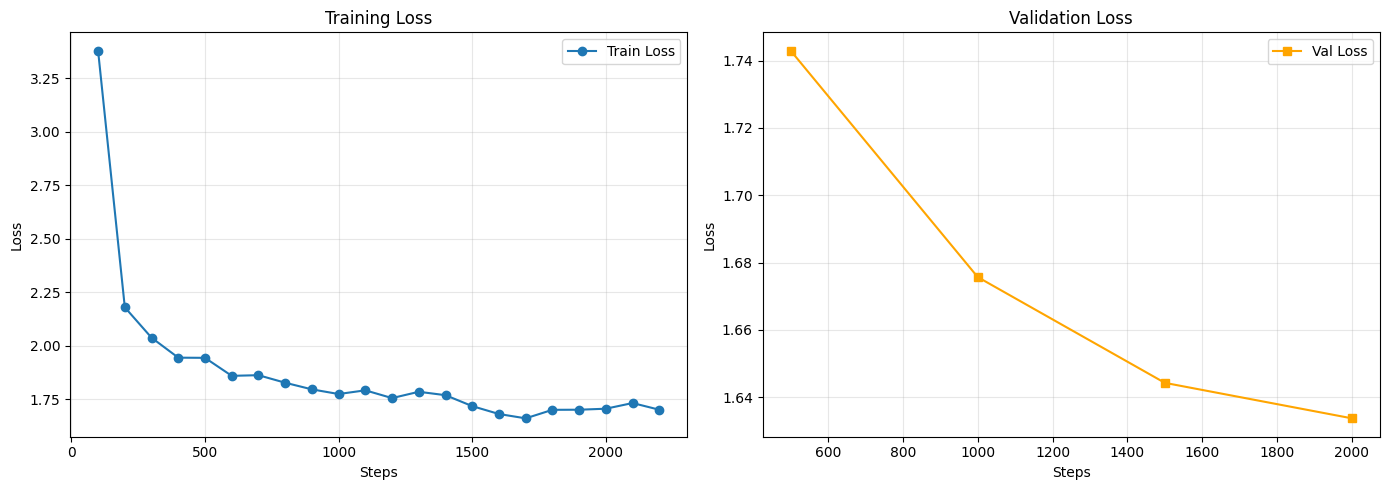


 You can now proceed to evaluation!


In [ ]:
# ============================================================
# PART 6: MODEL TRAINING
# ============================================================

# Create Trainer
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets['train'],
    eval_dataset=tokenized_datasets['validation'],
    tokenizer=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print(" Starting training...")
print(" Estimated time: 30-60 minutes for t5-small with 30k samples")
print("   (Time may vary depending on GPU and data size)\n")

# Train the model
train_result = trainer.train()

# Save the final model
final_model_dir = "./final_model"
trainer.save_model(final_model_dir)
tokenizer.save_pretrained(final_model_dir)

print("\n Training completed!")
print(f"   Training loss: {train_result.training_loss:.4f}")
print(f"   Model saved to: {final_model_dir}")

# Show training history
history_df = pd.DataFrame(trainer.state.log_history)
print("\n Training history (last 5 entries):")
print(history_df.tail())

# Plot training curves
if 'loss' in history_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Training loss
    train_logs = history_df[history_df['loss'].notna()]
    axes[0].plot(train_logs['step'], train_logs['loss'], marker='o', label='Train Loss')
    axes[0].set_xlabel('Steps')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Validation loss
    eval_logs = history_df[history_df['eval_loss'].notna()]
    if not eval_logs.empty:
        axes[1].plot(eval_logs['step'], eval_logs['eval_loss'], marker='s', color='orange', label='Val Loss')
        axes[1].set_xlabel('Steps')
        axes[1].set_ylabel('Loss')
        axes[1].set_title('Validation Loss')
        axes[1].legend()
        axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

print("\n You can now proceed to evaluation!")

#7. Quantitative Evaluation on Test Set
Assessing the model's performance on unseen data:

Prediction: Generating titles for the held-out Test Set.

Decoding: Converting predicted token IDs back into human-readable text (handling potential decoding errors/overflows).

Analysis: Comparing the length distribution of generated titles versus reference titles to ensure the model captures the correct output style.

In [ ]:
# ============================================================
# PART 7: MODEL EVALUATION
# ============================================================

print(" Evaluating model on test set...")

# 1. Generate predictions
print("\n Generating predictions on test set...")
predict_results = trainer.predict(tokenized_datasets['test'])

preds = predict_results.predictions
labels = predict_results.label_ids

# Check if preds is a tuple (common for T5 models), then take the first element
if isinstance(preds, tuple):
    preds = preds[0]

# Check if preds are Logits (3 dimensions: batch, sequence, vocab) -> Convert to Token IDs
# If the shape is (num_samples, sentence_length, vocab_size), then argmax is needed
if len(preds.shape) == 3:
    print(" Detected logits, converting to token IDs using argmax...")
    preds = np.argmax(preds, axis=-1)

# Handle -100 values (ignore index) in labels and preds
# Replace -100 with pad_token_id (usually 0) to avoid tokenizer errors
if tokenizer.pad_token_id is not None:
    pad_token_id = tokenizer.pad_token_id
else:
    pad_token_id = 0 # Fallback

# Ensure data is integer type
preds = preds.astype(int)
labels = labels.astype(int)

# Replace -100 with pad_token_id
preds = np.where(preds != -100, preds, pad_token_id)
labels = np.where(labels != -100, labels, pad_token_id)

print(f" Prediction shape after processing: {preds.shape}")

# 2. Decode (Convert IDs to text)
decoded_preds = tokenizer.batch_decode(preds, skip_special_tokens=True)
decoded_labels = tokenizer.batch_decode(labels, skip_special_tokens=True)

# Clean text (remove extra whitespace)
decoded_preds = [pred.strip() for pred in decoded_preds]
decoded_labels = [label.strip() for label in decoded_labels]

# 3. Create results dataframe
results_df = pd.DataFrame({
    'reference': decoded_labels,
    'generated': decoded_preds,
    'summary': test_df[summary_col].values[:len(decoded_preds)] # Ensure lengths match
})

print(f" Generated {len(results_df)} predictions")

# 4. Analyze prediction lengths
results_df['ref_length'] = results_df['reference'].str.split().str.len()
results_df['gen_length'] = results_df['generated'].str.split().str.len()

print("\n Length Statistics:")
print(f"  Reference - Mean: {results_df['ref_length'].mean():.1f}")
print(f"  Generated - Mean: {results_df['gen_length'].mean():.1f}")

# 5. Show some example predictions
print("\n Sample Predictions:")
print("="*80)
for i in range(min(5, len(results_df))):
    print(f"\nExample {i+1}:")
    print(f"Summary: {results_df.iloc[i]['summary'][:150]}...")
    print(f"Reference: {results_df.iloc[i]['reference']}")
    print(f"Generated: {results_df.iloc[i]['generated']}")
    print("-"*80)

# 6. Save results
results_df.to_csv('test_predictions.csv', index=False)
print("\n Results saved to 'test_predictions.csv'")

# 7. Compute Final Metrics (Optional but recommended)
try:
    final_metrics = compute_metrics((preds, labels))
    print("\n Final Test Metrics:")
    print(final_metrics)
except Exception as e:
    print(f"\n Could not compute final metrics directly: {e}")

 Evaluating model on test set...

 Generating predictions on test set...


 Prediction shape after processing: (2983, 64)
 Generated 2983 predictions

 Length Statistics:
  Reference - Mean: 9.1
  Generated - Mean: 8.1

 Sample Predictions:

Example 1:
Summary: Rationalization is fundamental to human reasoning and learning. NLP models
trained to produce rationales along with predictions, called
self-rationali...
Reference: Does Self-Rationalization Improve Robustness to Spurious Correlations?
Generated: Robustness to Spurious Correlations in Self-Rationalization Models
--------------------------------------------------------------------------------

Example 2:
Summary: Activation function is crucial to the recent successes of deep neural
networks. In this paper, we first propose a new activation function, Multiple
Pa...
Reference: Improving Deep Neural Network with Multiple Parametric Exponential Linear Units
Generated: Multiple Parametric Exponential Linear Units for Deep Neural Networks
-----------------------------------------------------------------------

# 8. Qualitative Analysis & Inference Demo
A deep dive into the quality of the generated titles:

Similarity Check: Calculating similarity scores to categorize predictions (High, Medium, Low match).

Manual Inspection: Reviewing specific examples to understand where the model excels or fails.

Interactive Inference: A custom function generate_title() allowing users to input any scientific abstract and receive a generated title in real-time.

In [ ]:
# ============================================================
# PART 8: QUALITATIVE ANALYSIS & INTERACTIVE TESTING
# ============================================================

# Function for interactive title generation
def generate_title(summary_text, num_beams=4, max_length=64, num_return_sequences=1):
    """
    Generate title from summary

    Args:
        summary_text: Input summary text
        num_beams: Number of beams for beam search
        max_length: Maximum length of generated title
        num_return_sequences: Number of titles to generate
    """
    # Prepare input
    input_text = "summarize: " + summary_text
    inputs = tokenizer(input_text, return_tensors="pt", max_length=512, truncation=True)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    # Generate
    model.to(device)
    model.eval()

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_length=max_length,
            num_beams=num_beams,
            num_return_sequences=num_return_sequences,
            early_stopping=True,
            no_repeat_ngram_size=2,
            length_penalty=1.0
        )

    # Decode
    titles = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]
    return titles

# Test with custom examples
print(" Testing with custom examples:\n")

test_examples = [
    """We present a novel approach to natural language processing using transformer-based
    architectures. Our method achieves state-of-the-art results on multiple benchmarks
    while being more computationally efficient than previous approaches.""",

    """This paper introduces a new algorithm for image segmentation based on deep learning.
    The proposed method combines convolutional neural networks with attention mechanisms
    to achieve superior performance on medical imaging datasets.""",
]

for i, example in enumerate(test_examples):
    print(f"Example {i+1}:")
    print(f"Summary: {example[:100]}...")
    print(f"\nGenerated Titles:")
    titles = generate_title(example, num_beams=5, num_return_sequences=3)
    for j, title in enumerate(titles):
        print(f"  {j+1}. {title}")
    print("\n" + "="*80 + "\n")

# Analyze quality categories
print(" Qualitative Analysis of Predictions:\n")

# Calculate similarity between reference and generated titles
from difflib import SequenceMatcher

def similarity_score(a, b):
    return SequenceMatcher(None, a.lower(), b.lower()).ratio()

results_df['similarity'] = results_df.apply(
    lambda row: similarity_score(row['reference'], row['generated']), axis=1
)

# Categorize predictions
results_df['category'] = pd.cut(
    results_df['similarity'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Match', 'Medium Match', 'High Match']
)

print("Quality Distribution:")
print(results_df['category'].value_counts().sort_index())

# Show examples from each category
print("\n Examples by Quality:\n")

for category in ['High Match', 'Medium Match', 'Low Match']:
    examples = results_df[results_df['category'] == category].head(2)
    print(f"\n{category} Examples:")
    print("="*80)
    for idx, row in examples.iterrows():
        print(f"Reference:  {row['reference']}")
        print(f"Generated:  {row['generated']}")
        print(f"Similarity: {row['similarity']:.2f}")
        print("-"*80)

# Interactive generation function
print("\n Interactive Title Generation Function Ready!")
print("Use: generate_title(your_summary, num_beams=4, max_length=64, num_return_sequences=3)")
print("\nExample:")
print("  titles = generate_title('Your abstract here...', num_return_sequences=3)")
print("  for i, title in enumerate(titles):")
print("      print(f'{i+1}. {title}')")

 Testing with custom examples:

Example 1:
Summary: We present a novel approach to natural language processing using transformer-based
    architectures...

Generated Titles:
  1. Transformer-based Natural Language Processing
  2. Transformer-Based Natural Language Processing
  3. Transformer-based natural language processing


Example 2:
Summary: This paper introduces a new algorithm for image segmentation based on deep learning.
    The propose...

Generated Titles:
  1. Deep Learning Algorithm for Medical Image Segmentation
  2. Deep Learning Algorithm for Image Segmentation
  3. Deep Learning Algorithm for Medical Imaging Segmentation


 Qualitative Analysis of Predictions:

Quality Distribution:
category
Low Match        214
Medium Match    1699
High Match      1070
Name: count, dtype: int64

 Examples by Quality:


High Match Examples:
Reference:  FastClass: A Time-Efficient Approach to Weakly-Supervised Text Classification
Generated:  FastClass: Efficient Weakly-Supervised Text 